In [553]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , roc_auc_score, roc_curve
import os

In [554]:
train = pd.read_csv(os.path.join("..", "spaceship titanic", "train.csv"))
test = pd.read_csv(os.path.join("..", "spaceship titanic", "test.csv"))

In [555]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [556]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [557]:
train.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [558]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 1.2+ MB


## test :

In [559]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [560]:
test.isna().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [561]:
test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [562]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   str    
 1   HomePlanet    4190 non-null   str    
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   str    
 4   Destination   4185 non-null   str    
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   str    
dtypes: float64(6), object(2), str(5)
memory usage: 617.2+ KB


## EDA

` AgeBin `

In [563]:
train["AgeBin"] = pd.cut(
    train["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

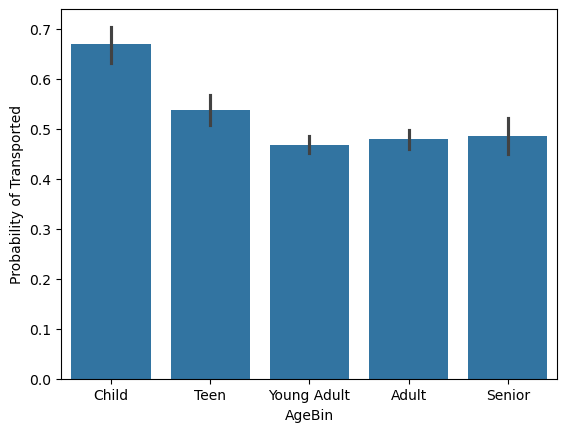

In [564]:
sns.barplot(data=train, x="AgeBin", y="Transported")
plt.ylabel("Probability of Transported")
plt.show()


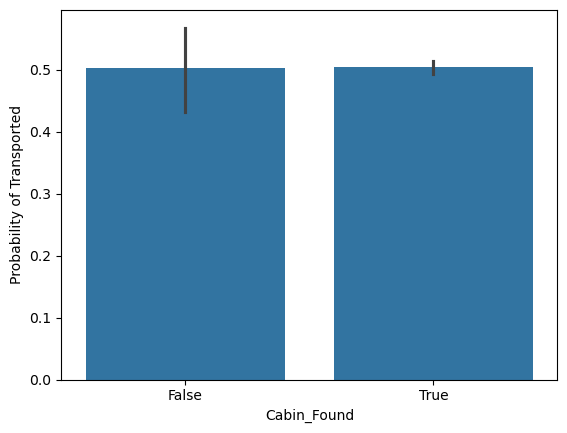

In [565]:
train["Cabin_Found"] = train["Cabin"].notna()

sns.barplot(data=train, x="Cabin_Found", y="Transported")
plt.ylabel("Probability of Transported")
plt.show()


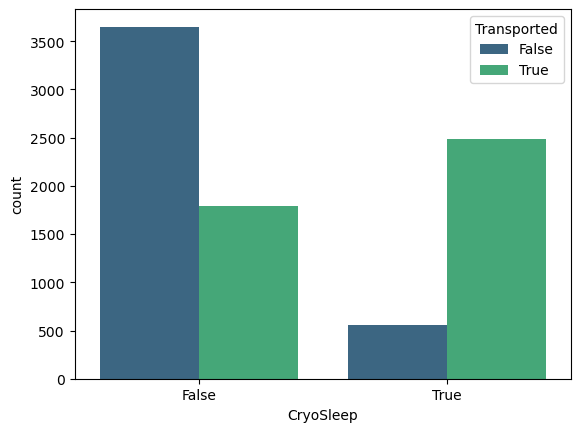

In [566]:
sns.countplot(data=train, x='CryoSleep', hue='Transported', palette='viridis')
plt.show()

In [567]:
train[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = train[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)
train.isnull().sum().sort_values(ascending=False)

AgeBin          357
HomePlanet      201
Name            200
Cabin           199
Destination     182
RoomService     181
Age             179
PassengerId       0
VIP               0
CryoSleep         0
FoodCourt         0
ShoppingMall      0
VRDeck            0
Spa               0
Transported       0
Cabin_Found       0
dtype: int64

In [568]:
feature = ["HomePlanet","CryoSleep","RoomService", "Spa", "VRDeck","Deck","Side","AgeBin"]

y = train["Transported"]
x = train.drop(["PassengerId", 'Transported',"Name"], axis=1)

x[["Deck", "CabinNum", "Side"]] = x["Cabin"].str.split("/", expand=True)
x = x.drop("Cabin", axis=1)

x["CabinNum"] = pd.to_numeric(x["CabinNum"], errors="coerce") 

categorical_cols = ["HomePlanet", "CryoSleep", "Deck", "Side", "AgeBin"]
x = pd.get_dummies(x[feature], columns=categorical_cols, dummy_na=True)
x = x.fillna(0)


xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.20, random_state=42)


In [569]:
DTs = DecisionTreeClassifier(
    min_samples_split=35,
    max_depth=10,
    random_state=42,
    min_samples_leaf=2
)

DTs.fit(xTrain, yTrain)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",35
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [570]:
pred = DTs.predict(xTest)
print("Accuracy:", accuracy_score(yTest, pred))
print("ROC AUC Score:", roc_auc_score(yTest, pred))
print("Confusion Matrix:\n", confusion_matrix(yTest, pred))
print("Classification Report:\n", classification_report(yTest, pred))

Accuracy: 0.7722829212190915
ROC AUC Score: 0.771676468798531
Confusion Matrix:
 [[611 250]
 [146 732]]
Classification Report:
               precision    recall  f1-score   support

       False       0.81      0.71      0.76       861
        True       0.75      0.83      0.79       878

    accuracy                           0.77      1739
   macro avg       0.78      0.77      0.77      1739
weighted avg       0.78      0.77      0.77      1739



In [571]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


auc_scores = cross_val_score(
    DTs,
    x,
    y,
    cv=kfold,
    scoring="roc_auc",
    n_jobs=-1
)

print("K-Fold ROC AUC Scores:", auc_scores)
print("Mean ROC AUC:", auc_scores.mean())
print("ROC AUC Std:", auc_scores.std())

K-Fold ROC AUC Scores: [0.86743044 0.85282835 0.85096721 0.86778149 0.84040656]
Mean ROC AUC: 0.8558828093265275
ROC AUC Std: 0.010468367614475836


In [572]:
from sklearn.metrics import roc_auc_score
import joblib

best_score = -1
best_model = None

for train_idx, val_idx in kfold.split(x, y):

    X_train = x.iloc[train_idx]
    X_val = x.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = DecisionTreeClassifier(
        min_samples_split=2,
        max_depth=10,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]

    score = roc_auc_score(y_val, y_prob)

    print("Fold ROC AUC:", score)

    if score > best_score:
        best_score = score
        best_model = model

print("\nBest ROC AUC:", best_score)

joblib.dump(best_model, "best_decision_tree.pkl")

Fold ROC AUC: 0.8545221617274348
Fold ROC AUC: 0.8377196463435925
Fold ROC AUC: 0.8455914644147792
Fold ROC AUC: 0.8519576229101142
Fold ROC AUC: 0.8242463168349611

Best ROC AUC: 0.8545221617274348


['best_decision_tree.pkl']

In [573]:
# %% 
# Prepare test data using the SAME preprocessing as training

test["AgeBin"] = pd.cut(
    test["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Extract Deck, CabinNum, and Side
test[["Deck", "CabinNum", "Side"]] = test["Cabin"].str.split(
    "/", expand=True
)

test = test.drop("Cabin", axis=1)

test["CabinNum"] = pd.to_numeric(
    test["CabinNum"],
    errors="coerce"
)

# Same categorical columns
categorical_cols = [
    "HomePlanet",
    "CryoSleep",
    "Deck",
    "Side",
    "AgeBin"
]

# Create dummy variables
test_features = pd.get_dummies(
    test[feature],
    columns=categorical_cols,
    dummy_na=True
)

test_features = test_features.fillna(0)

# Make absolutely sure test columns match training columns
test_features = test_features.reindex(
    columns=x.columns,
    fill_value=0
)

# %% 
# Load the best saved model
DT = joblib.load("best_decision_tree.pkl")

# Predict
predictions = DT.predict(test_features)

# %% 
# Create Kaggle submission
submission_df = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": predictions.astype(bool)
})

submission_df.to_csv("submission.csv", index=False)

print(submission_df.head())
print("\nSubmission shape:", submission_df.shape)

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True

Submission shape: (4277, 2)
